In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load datasets

In [2]:
customers_df = pd.read_csv("Customers.csv")
products_df = pd.read_csv("Products.csv")
transactions_df = pd.read_csv("Transactions.csv")

In [3]:
customers_df.head()

,CustomerID,CustomerName,Region,SignupDate
0,C0001,Lawrence Carroll,South America,2022-07-10
1,C0002,Elizabeth Lutz,Asia,2022-02-13
2,C0003,Michael Rivera,South America,2024-03-07
3,C0004,Kathleen Rodriguez,South America,2022-10-09
4,C0005,Laura Weber,Asia,2022-08-15


In [4]:
products_df.head()

,ProductID,ProductName,Category,Price
0,P001,ActiveWear Biography,Books,169.30
1,P002,ActiveWear Smartwatch,Electronics,346.30
2,P003,ComfortLiving Biography,Books,44.12
3,P004,BookWorld Rug,Home Decor,95.69
4,P005,TechPro T-Shirt,Clothing,429.31


In [5]:
transactions_df.head()

,TransactionID,CustomerID,ProductID,TransactionDate,Quantity,TotalValue,Price
0,T00001,C0199,P067,2024-08-25 12:38:23,1,300.68,300.68
1,T00112,C0146,P067,2024-05-27 22:23:54,1,300.68,300.68
2,T00166,C0127,P067,2024-04-25 7:38:55,1,300.68,300.68
3,T00272,C0087,P067,2024-03-26 22:55:37,2,601.36,300.68
4,T00363,C0070,P067,2024-03-21 15:10:10,3,902.04,300.68


In [6]:
# Display basic information and first few rows
print(transactions_df.info())
print(transactions_df.head())

print(products_df.info())
print(products_df.head())

print(customers_df.info())
print(customers_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TransactionID    1000 non-null   object 
 1   CustomerID       1000 non-null   object 
 2   ProductID        1000 non-null   object 
 3   TransactionDate  1000 non-null   object 
 4   Quantity         1000 non-null   int64  
 5   TotalValue       1000 non-null   float64
 6   Price            1000 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 54.8+ KB
None
  TransactionID CustomerID ProductID      TransactionDate  Quantity  \
0        T00001      C0199      P067  2024-08-25 12:38:23         1   
1        T00112      C0146      P067  2024-05-27 22:23:54         1   
2        T00166      C0127      P067   2024-04-25 7:38:55         1   
3        T00272      C0087      P067  2024-03-26 22:55:37         2   
4        T00363      C0070      P067  2024-03-21 15:10:10 

In [7]:
# Convert date columns to datetime format
customers_df["SignupDate"] = pd.to_datetime(customers_df["SignupDate"])
transactions_df["TransactionDate"] = pd.to_datetime(transactions_df["TransactionDate"])

In [8]:
# Merge transactions with customers and products
data = transactions_df.merge(customers_df, on="CustomerID", how="left").merge(products_df, on="ProductID", how="left")

In [9]:
# Summary statistics
print("Customers Summary:")
print(customers_df.describe(include='all'))
print("\nProducts Summary:")
print(products_df.describe(include='all'))
print("\nTransactions Summary:")
print(transactions_df.describe(include='all'))

Customers Summary:
       CustomerID      CustomerName         Region           SignupDate
count         200               200            200                  200
unique        200               200              4                  NaN
top         C0001  Lawrence Carroll  South America                  NaN
freq            1                 1             59                  NaN
mean          NaN               NaN            NaN  2023-07-19 08:31:12
min           NaN               NaN            NaN  2022-01-22 00:00:00
25%           NaN               NaN            NaN  2022-09-26 12:00:00
50%           NaN               NaN            NaN  2023-08-31 12:00:00
75%           NaN               NaN            NaN  2024-04-12 12:00:00
max           NaN               NaN            NaN  2024-12-28 00:00:00

Products Summary:
       ProductID            ProductName Category       Price
count        100                    100      100  100.000000
unique       100                     66        4

In [10]:
# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
TransactionID      0
CustomerID         0
ProductID          0
TransactionDate    0
Quantity           0
TotalValue         0
Price_x            0
CustomerName       0
Region             0
SignupDate         0
ProductName        0
Category           0
Price_y            0
dtype: int64


### Top selling products

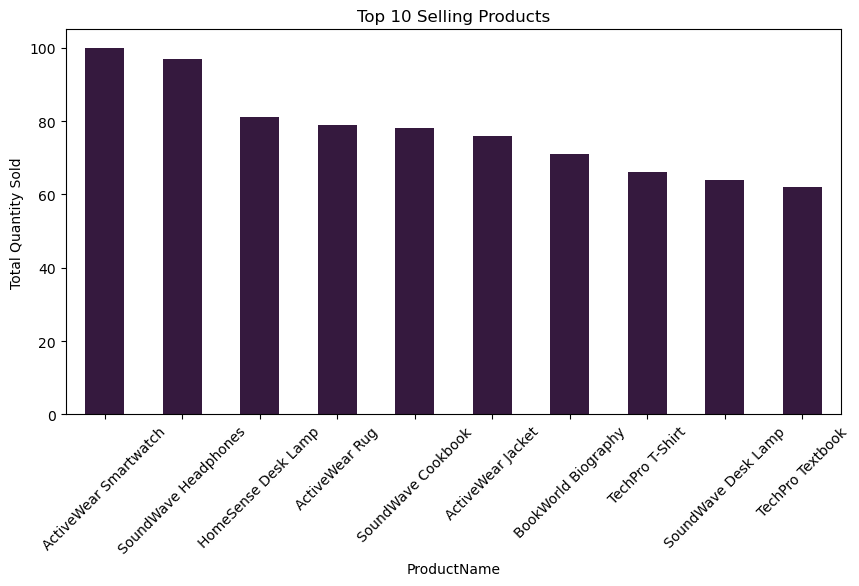

In [11]:
top_products = data.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_products.plot(kind="bar", color=sns.color_palette("rocket")[0])
plt.title("Top 10 Selling Products")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.show()

### Sales distribution by region

C:\Users\Shridhar\AppData\Local\Temp\ipykernel_5048\2800072587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Region", y="TotalValue", data=data, palette="rocket")


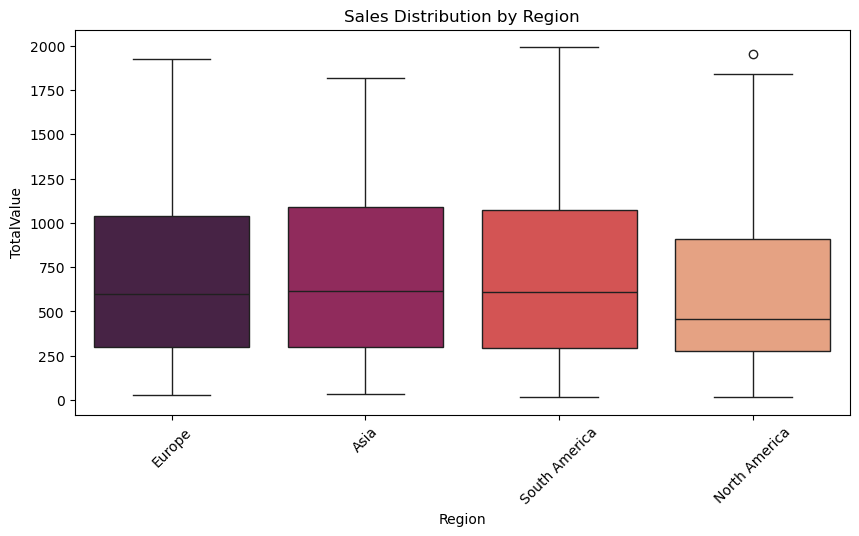

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Region", y="TotalValue", data=data, palette="rocket")
plt.title("Sales Distribution by Region")
plt.xticks(rotation=45)
plt.show()

### Customer signup trend

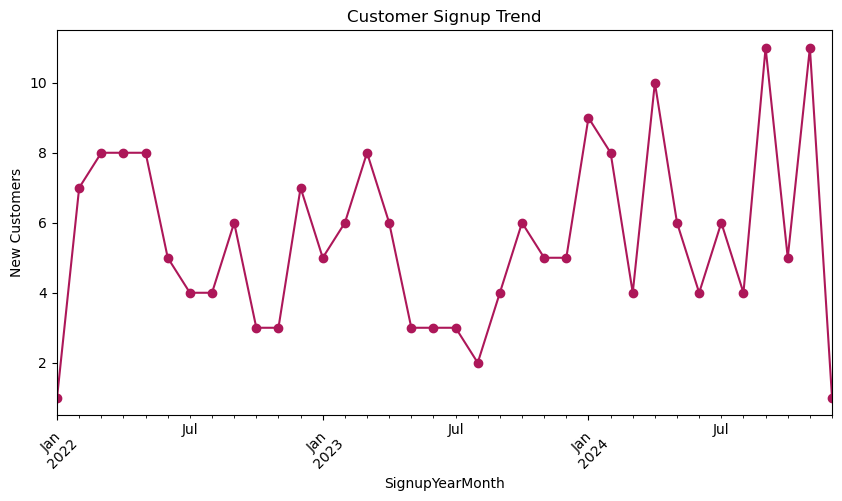

In [13]:
data["SignupYearMonth"] = data["SignupDate"].dt.to_period("M")
signup_trend = data.groupby("SignupYearMonth")["CustomerID"].nunique()
plt.figure(figsize=(10,5))
signup_trend.plot(marker="o", color=sns.color_palette("rocket")[2])
plt.title("Customer Signup Trend")
plt.ylabel("New Customers")
plt.xticks(rotation=45)
plt.show()

### Revenue trend over time

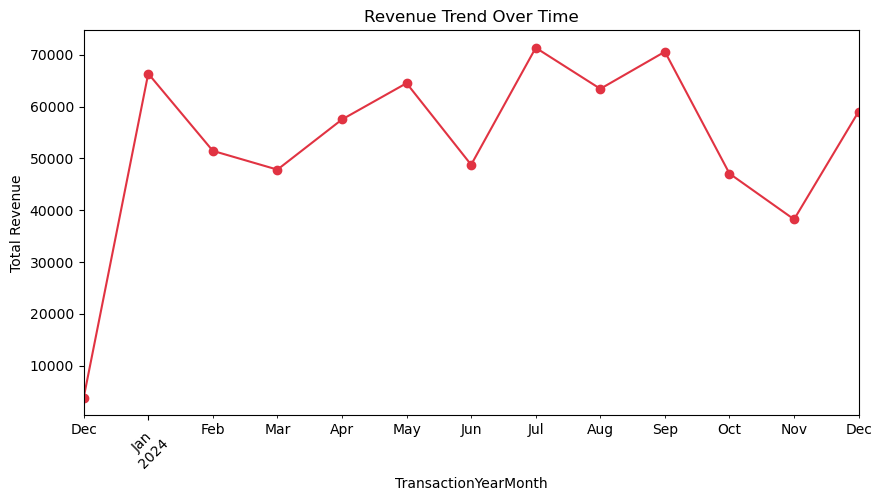

In [14]:
data["TransactionYearMonth"] = data["TransactionDate"].dt.to_period("M")
revenue_trend = data.groupby("TransactionYearMonth")["TotalValue"].sum()
plt.figure(figsize=(10,5))
revenue_trend.plot(marker="o", color=sns.color_palette("rocket")[3])
plt.title("Revenue Trend Over Time")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

### Customer segments based on purchase amount

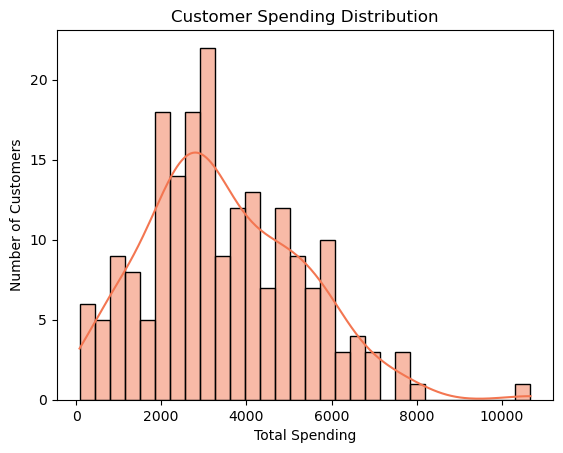

In [15]:
customer_spending = data.groupby("CustomerID")["TotalValue"].sum()
sns.histplot(customer_spending, bins=30, kde=True, color=sns.color_palette("rocket")[4])
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()